In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Load dataset
df = pd.read_csv('houseprices.csv')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset info:")
print(df.info())

Dataset shape: (18, 4)

First few rows:
   area  bedrooms  age  price
0  2500       3.0   20    110
1  2650       3.0   15    155
2  2100       4.0   10    150
3  2600       3.0    5    285
4  2400       3.0   35     50

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   area      18 non-null     int64  
 1   bedrooms  17 non-null     float64
 2   age       18 non-null     int64  
 3   price     18 non-null     int64  
dtypes: float64(1), int64(3)
memory usage: 708.0 bytes
None


In [3]:
# Handle missing values
df = df.dropna()
print("Dataset shape after removing missing values:", df.shape)

Dataset shape after removing missing values: (17, 4)


In [4]:
# Separate features and target
# X = df['Area', 'Bedrooms', 'Age']
X = df.drop('price', axis=1)
y = df['price']

print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())

Features (X):
   area  bedrooms  age
0  2500       3.0   20
1  2650       3.0   15
2  2100       4.0   10
3  2600       3.0    5
4  2400       3.0   35

Target (y):
0    110
1    155
2    150
3    285
4     50
Name: price, dtype: int64


In [5]:
# Split data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 13
Test set size: 4


In [6]:
# Train the Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
# Make predictions
y_pred = model.predict(X_test)

print("Predictions on test set:")
for i in range(len(y_test)):
    print(f"Actual: {y_test.iloc[i]:.2f}, Predicted: {y_pred[i]:.2f}")

Predictions on test set:
Actual: 110.00, Predicted: 148.06
Actual: 155.00, Predicted: 191.84
Actual: 130.00, Predicted: 166.65
Actual: 95.00, Predicted: 26.03


In [8]:
# Calculate evaluation metrics (MSE, MAE, F2-Score which is R2-Score)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluation Metrics:")
print(f"MSE (Mean Squared Error): {mse:.2f}")
print(f"MAE (Mean Absolute Error): {mae:.2f}")
print(f"R2 Score (F2-Score): {r2:.4f}")

Evaluation Metrics:
MSE (Mean Squared Error): 2226.40
MAE (Mean Absolute Error): 45.13
R2 Score (F2-Score): -3.3978


In [9]:
# Print Coefficient and Intercept values
print("Model Coefficients:")
for i, col in enumerate(X.columns):
    print(f"{col}: {model.coef_[i]:.4f}")

print(f"\nIntercept: {model.intercept_:.4f}")

Model Coefficients:
area: 0.0620
bedrooms: -34.4481
age: -6.8963

Intercept: 234.4331


In [10]:
# Test the model with real data (new house data)
new_house = [[2700, 3, 12]]  # area=2700, bedrooms=3, age=12
predicted_price = model.predict(new_house)

print("Testing with new data:")
print(f"House: Area=2700 sqft, Bedrooms=3, Age=12 years")
print(f"Predicted Price: ${predicted_price[0]:.2f}K")

Testing with new data:
House: Area=2700 sqft, Bedrooms=3, Age=12 years
Predicted Price: $215.62K


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


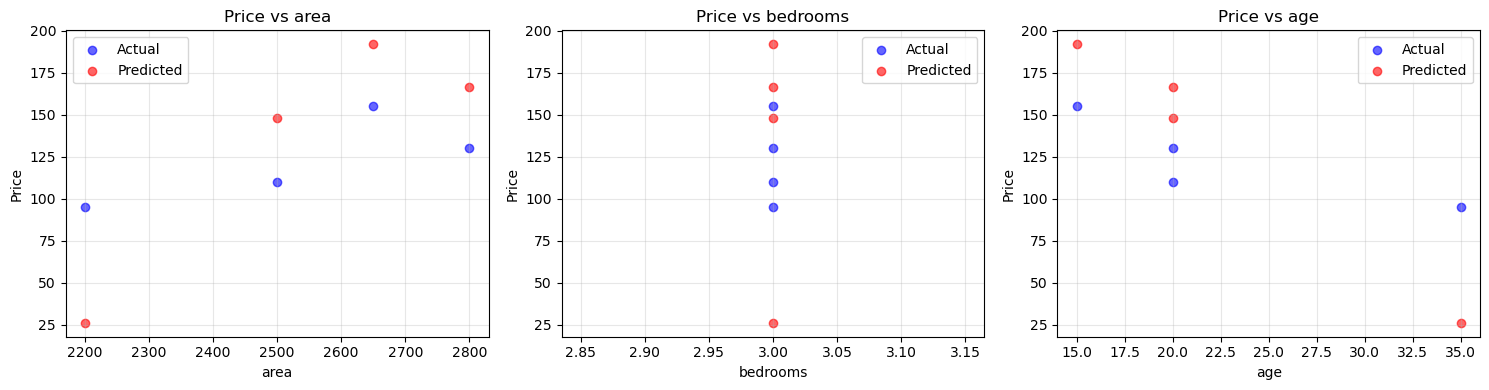

In [11]:
# Plot input features and regression line
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot for each feature
features = X.columns
for i, feature in enumerate(features):
    axes[i].scatter(X_test[feature], y_test, color='blue', label='Actual', alpha=0.6)
    axes[i].scatter(X_test[feature], y_pred, color='red', label='Predicted', alpha=0.6)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Price')
    axes[i].set_title(f'Price vs {feature}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

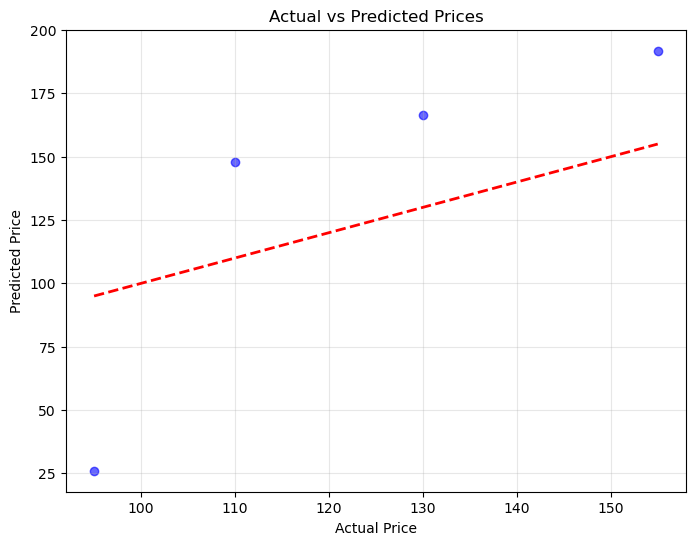

In [12]:
# Additional plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# Discussion: Model Performance Analysis
print("=" * 60)
print("MODEL PERFORMANCE DISCUSSION")
print("=" * 60)

print(f"\n1. R2 Score: {r2:.4f}")
if r2 > 0.9:
    print("   → Excellent fit! The model explains over 90% of the variance.")
elif r2 > 0.7:
    print("   → Good fit. The model explains a significant portion of variance.")
elif r2 > 0.5:
    print("   → Moderate fit. There's room for improvement.")
else:
    print("   → Poor fit. The model may need more features or different approach.")

print(f"\n2. MSE: {mse:.2f}")
print(f"   → Average squared error of ${mse:.2f}K")
print(f"   → Root MSE: ${np.sqrt(mse):.2f}K (typical prediction error)")

print(f"\n3. MAE: {mae:.2f}")
print(f"   → On average, predictions are off by ${mae:.2f}K")

print("\n4. Feature Importance (based on coefficients):")
for i, col in enumerate(X.columns):
    print(f"   → {col}: {model.coef_[i]:.4f}")
    if col == 'area':
        print(f"      Each additional sqft increases price by ${model.coef_[i]:.4f}K")
    elif col == 'bedrooms':
        print(f"      Each additional bedroom changes price by ${model.coef_[i]:.4f}K")
    elif col == 'age':
        print(f"      Each additional year of age changes price by ${model.coef_[i]:.4f}K")

print("\n5. Overall Assessment:")
print("   The Multiple Linear Regression model uses area, bedrooms, and age")
print("   to predict house prices. The model's performance depends on:")
print("   - How well the features correlate with the price")
print("   - Whether the relationship is truly linear")
print("   - The quality and size of the training data")
print("=" * 60)

MODEL PERFORMANCE DISCUSSION

1. R2 Score: -3.3978
   → Poor fit. The model may need more features or different approach.

2. MSE: 2226.40
   → Average squared error of $2226.40K
   → Root MSE: $47.18K (typical prediction error)

3. MAE: 45.13
   → On average, predictions are off by $45.13K

4. Feature Importance (based on coefficients):
   → area: 0.0620
      Each additional sqft increases price by $0.0620K
   → bedrooms: -34.4481
      Each additional bedroom changes price by $-34.4481K
   → age: -6.8963
      Each additional year of age changes price by $-6.8963K

5. Overall Assessment:
   The Multiple Linear Regression model uses area, bedrooms, and age
   to predict house prices. The model's performance depends on:
   - How well the features correlate with the price
   - Whether the relationship is truly linear
   - The quality and size of the training data
